In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Style settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Load data
df = pd.read_csv("train.csv")

# First look
print("Shape:", df.shape)
df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
df.info()
print("\n Missing Values\n", df.isnull().sum())
print("\n Basic stats\n", df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

 Missing Values
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [3]:
# This is like taking a photocopy of a document,
# writing on the photocopy, and expecting the original to change
# df["Age"].fillna(df["Age"].median(), inplace = True)
df["Age"] = df["Age"].fillna(df["Age"].median())
# df["Embarked"].fillna(df["Embarked"].mode()[0], inplace = True)
# df.drop(columns=["Cabin"])
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df.drop(columns=["Cabin"], inplace=True)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 76.7 KB


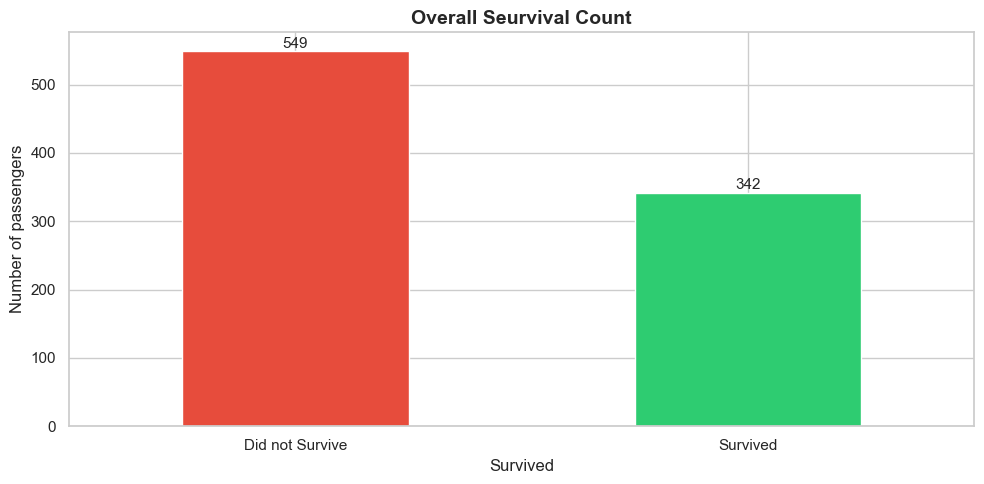

In [5]:
ax = df["Survived"].value_counts().plot(kind="bar", color=["#E74C3C", "#2ECC71"], edgecolor="white", width=0.5)
ax.set_xticklabels(["Did not Survive","Survived"], rotation=0)
ax.set_ylabel("Number of passengers")
ax.set_title("Overall Seurvival Count",fontsize=14, fontweight="bold")
for p in ax.patches:
    ax.annotate(f'{p.get_height()}',(p.get_x() + p.get_width()/2, p.get_height() + 5),
                ha='center', fontsize=11)
plt.tight_layout()
plt.savefig("survival_count.png", dpi=150)
plt.show()

In [6]:
Survival_by_sex = df.groupby("Sex")["Survived"].mean().reset_index()
Survival_by_sex["Survived"] = (Survival_by_sex["Survived"]*100).round(1)

/var/folders/hw/cxt4l_057rj1bbndr7ksmd8m0000gn/T/ipykernel_64484/538110525.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=Survival_by_sex, x="Sex", y="Survived",


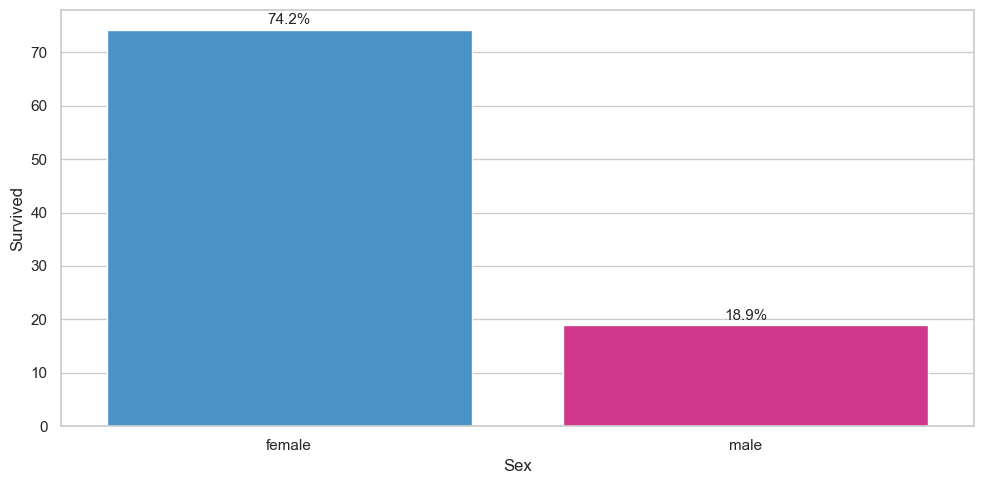

In [7]:
ax = sns.barplot(data=Survival_by_sex, x="Sex", y="Survived",
                 palette=["#3498DB", "#E91E8C"])
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width()/2, p.get_height() + 1),
                ha='center', fontsize=11)
plt.tight_layout()
plt.savefig("Survival_by_gender.png", dpi=150)
plt.show()

/var/folders/hw/cxt4l_057rj1bbndr7ksmd8m0000gn/T/ipykernel_64484/1921514778.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=Survival_by_class, x="Pclass", y="Survived", palette="Blues_d")


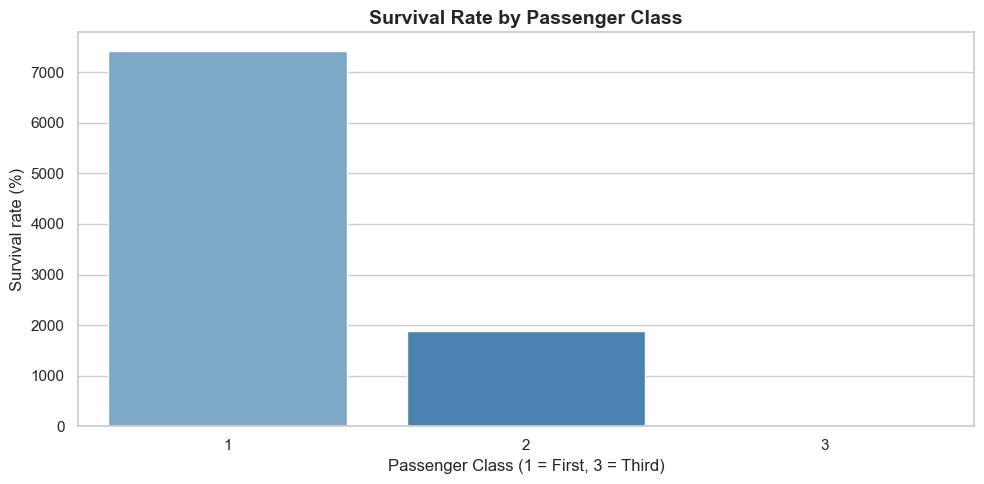

In [8]:
Survival_by_class = df.groupby("Pclass")["Survived"].mean().reset_index()
Survival_by_class["Survived"] = (Survival_by_sex["Survived"]*100).round(1)
ax = sns.barplot(data=Survival_by_class, x="Pclass", y="Survived", palette="Blues_d")
ax.set_title("Survival Rate by Passenger Class", fontsize=14, fontweight="bold")
ax.set_xlabel("Passenger Class (1 = First, 3 = Third)")
ax.set_ylabel("Survival rate (%)")
plt.tight_layout()
plt.savefig("survival_by_class.png", dpi=150)   # ← before show
plt.show()

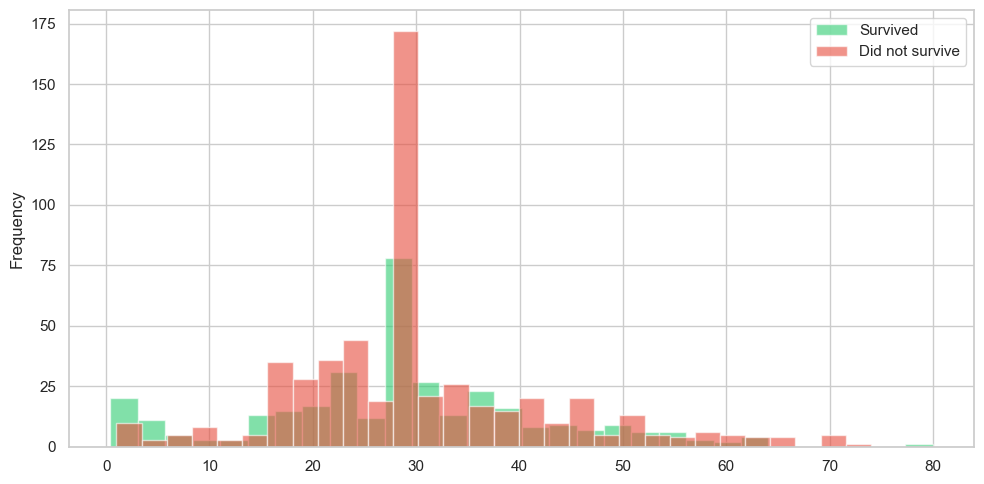

In [9]:
fig, ax = plt.subplots()
df[df["Survived"]==1]["Age"].plot(kind="hist", bins=30, alpha=0.6,color="#2ECC71", label="Survived", ax=ax)
df[df["Survived"]==0]["Age"].plot(kind="hist", bins=30, alpha=0.6,color="#E74C3C", label="Did not survive", ax=ax)
ax.legend()
plt.tight_layout()
plt.savefig("age_distribution.png", dpi=150)   # ← before show
plt.show()


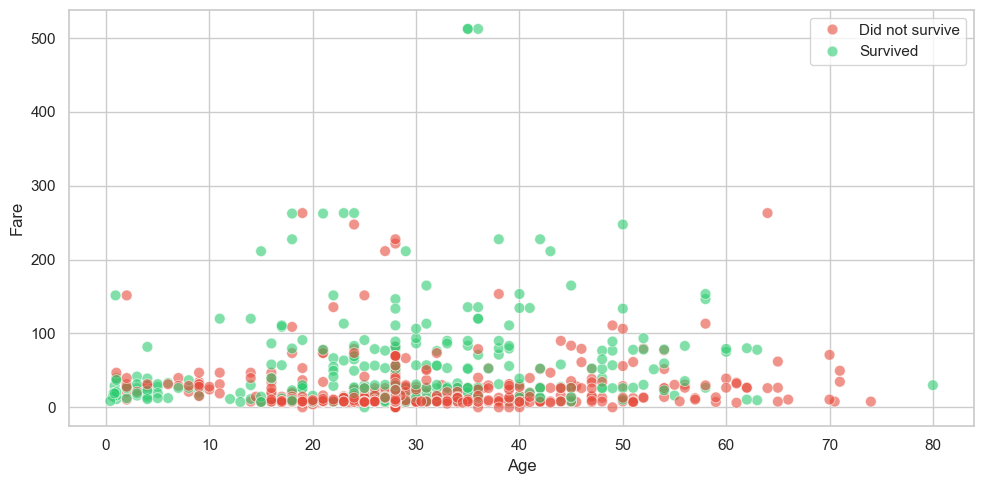

In [10]:
ax = sns.scatterplot(data = df,x="Age", y="Fare", hue="Survived",
                     palette={0: "#E74C3C", 1: "#2ECC71"}, alpha=0.6, s=60)
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ["Did not survive", "Survived"])
plt.tight_layout()
plt.savefig("fare_vs_age.png", dpi=150)   # ← before show
plt.show()

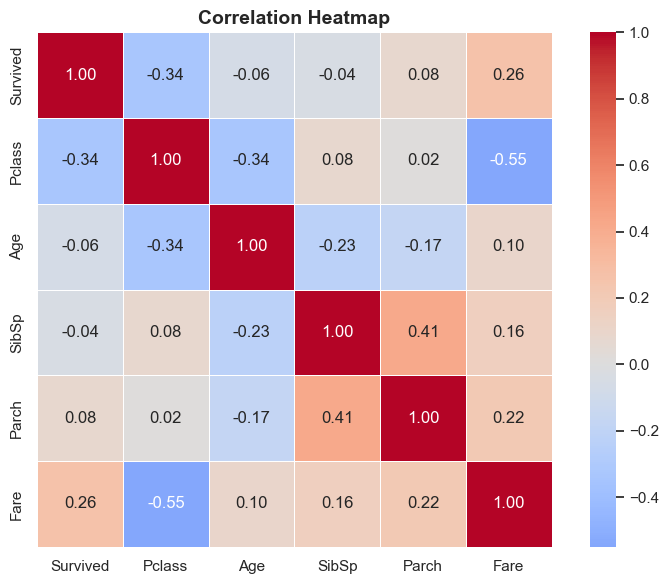

In [11]:
numeric_cols = df[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]]
corr = numeric_cols.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

## Key Findings

1. **Gender was the strongest survival factor** — 74% of women survived vs only 19% of men.
2. **Class mattered significantly** — 1st class had 63% survival rate vs 24% for 3rd class.
3. **Children had higher survival rates** — age histogram shows more survivors under age 10.
4. **Higher fare correlates with survival** — expensive tickets = higher class = better lifeboat access.
5. **Pclass and Fare are negatively correlated (-0.55)** — higher class number means cheaper ticket.